# Evidence-Backed Analysis: 2014-2016 Ebola Outbreak

This notebook analyzes the 2014-2016 West Africa Ebola outbreak using a cleaned WHO/HDX-derived country-level dataset and claim-ready evidence from WHO, CDC, and academic sources.

The analysis is descriptive by design. It compares reporting coverage, country-level burden, mortality patterns, time-series evolution, source-backed intervention milestones, and Nigeria as a documented contrast case. Intervention timing is used as context only; the notebook does not estimate causal effects.


## Reader Guide

The notebook follows a publication-oriented path:

1. Outbreak context and project scope.
2. Dataset construction, reporting coverage, and methodological caveats.
3. Country burden, mortality patterns, and CFR denominator context.
4. Time-series evolution for Sierra Leone, Liberia, and Guinea.
5. Source-backed intervention context and Nigeria as a contrast case.
6. Evidence boundaries, lessons, limitations, and conclusion.

All quantitative findings are recalculated from the processed dataset inside this notebook. Public health interpretation is bounded by the evidence tracker and source documentation.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        """Fallback display for non-notebook validation environments."""
        print(obj)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

plt.style.use("seaborn-v0_8-whitegrid")
CHART_COLOR = "#2f6f9f"
SECONDARY_COLOR = "#8fb8de"
ACCENT_COLOR = "#c95f3b"
GRID_COLOR = "#dddddd"
LINE_COLORS = {
    "Sierra Leone": CHART_COLOR,
    "Liberia": ACCENT_COLOR,
    "Guinea": "#4c956c",
}

EXPECTED_ROW_COUNT = 2379
EXPECTED_COUNTRY_COUNT = 10
EXPECTED_COLUMNS = [
    "Indicator_cases",
    "Country",
    "Date",
    "cases",
    "Indicator_deaths",
    "deaths",
]
EXPECTED_COUNTRIES = {
    "Guinea",
    "Liberia",
    "Sierra Leone",
    "Nigeria",
    "Mali",
    "Senegal",
    "Italy",
    "Spain",
    "United Kingdom",
    "United States of America",
}
EXCLUDED_CONTINUATION_LABELS = {"Liberia 2", "Guinea 2"}
TOP_THREE_COUNTRIES = ["Sierra Leone", "Liberia", "Guinea"]


def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for path in candidates:
        if (path / "README.md").exists() and (path / "datasets").exists() and (path / "notebooks").exists():
            return path
    raise FileNotFoundError(
        "Could not find project root containing README.md, datasets/, and notebooks/."
    )


PROJECT_ROOT = find_project_root()
PROCESSED_DATA_FILE = PROJECT_ROOT / "datasets" / "processed" / "master_cases_deaths.csv"


def make_coverage_summary(data):
    """Summarize reporting coverage by country with first/last report dates and row counts."""
    required = {"Country", "Date"}
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"Coverage summary missing required columns: {sorted(missing)}")

    coverage = (
        data.groupby("Country", as_index=False)
        .agg(
            first_report=("Date", "min"),
            last_report=("Date", "max"),
            report_count=("Date", "size"),
        )
        .rename(columns={"Country": "country"})
        .sort_values(["report_count", "country"], ascending=[False, True])
        .reset_index(drop=True)
    )
    return coverage


def make_burden_summary(data):
    """Summarize maximum cumulative cases and deaths by country."""
    required = {"Country", "cases", "deaths"}
    missing = required - set(data.columns)
    if missing:
        raise ValueError(f"Burden summary missing required columns: {sorted(missing)}")

    burden = (
        data.groupby("Country", as_index=False)
        .agg(total_cases=("cases", "max"), total_deaths=("deaths", "max"))
        .rename(columns={"Country": "country"})
        .sort_values(["total_cases", "country"], ascending=[False, True])
        .reset_index(drop=True)
    )
    return burden


def calculate_cfr(burden_table):
    """Add descriptive case fatality ratio percentage to a country burden table."""
    required = {"country", "total_cases", "total_deaths"}
    missing = required - set(burden_table.columns)
    if missing:
        raise ValueError(f"CFR calculation missing required columns: {sorted(missing)}")

    result = burden_table.copy()
    result["cfr_percent"] = (
        result["total_deaths"].div(result["total_cases"]).mul(100).where(result["total_cases"] > 0)
    )
    return result


def format_count(value, _position=None):
    """Format chart axes as whole-number counts with commas."""
    return f"{value:,.0f}"


def add_horizontal_bar_labels(ax, values, padding=0.01, formatter=format_count):
    """Add readable value labels to horizontal bars."""
    max_value = max(values) if len(values) else 0
    offset = max_value * padding if max_value else 0.1
    for bar, value in zip(ax.patches, values):
        ax.text(
            bar.get_width() + offset,
            bar.get_y() + bar.get_height() / 2,
            formatter(value),
            va="center",
            fontsize=9,
        )


def style_axis(ax):
    """Apply shared chart styling for publication-oriented notebook figures."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8)
    ax.grid(axis="y", visible=False)


def style_time_axis(ax):
    """Apply shared styling and readable date labels for time-series charts."""
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", labelrotation=45)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="both", color=GRID_COLOR, linewidth=0.8)


## 1. Title and Executive Summary

The 2014-2016 West Africa Ebola outbreak was historically severe, and WHO describes it as the largest Ebola outbreak recorded since the virus was discovered. This notebook uses the cleaned project dataset to examine how reported burden was distributed across countries, how cumulative cases and deaths evolved over time, and how source-backed response milestones can be used as context without implying causal effects.

Three findings structure the analysis. First, within the cleaned `main_countries` dataset, reported cases and deaths are heavily concentrated in Sierra Leone, Liberia, and Guinea. Second, interpretation depends on denominator and data-quality context: reporting coverage varies by country, derived `new_cases` come from changes in cumulative totals, and CFR values are unstable for countries with very small case counts. Third, Nigeria provides a documented contrast case, with CDC and academic sources describing rapid coordination, contact tracing, isolation/case management, and communication activities. Nigeria is not used as a direct counterfactual for the three hardest-hit countries.

The notebook's main contribution is not a causal claim. It is a transparent, evidence-bounded data story that separates what the cleaned dataset can describe from what public health sources can support.


## 2. Data Sources and Scope

The analysis uses `datasets/processed/master_cases_deaths.csv`, a cleaned country-date dataset derived from the WHO/HDX Ebola cases and deaths source. The selected indicators are cumulative confirmed, probable, and suspected Ebola cases and deaths. They are useful for broad descriptive analysis, but they are not confirmed-only counts and may differ from WHO headline totals. Minor discrepancies may exist between totals reported in the WHO outbreak dataset and totals published in later retrospective reports. To maintain consistency across countries and reporting periods, this project uses the WHO/HDX outbreak dataset as the analytical source of record.

The processed dataset preserves one row per country-date for 10 main country labels. `Liberia 2` and `Guinea 2` are excluded from `main_countries` because the exploratory notebook found that directly merging those continuation labels into Liberia and Guinea creates duplicate country-date rows. Their literal source meaning remains unresolved, so the safest primary analysis choice is to preserve the validated country-date grain.


In [2]:
DATA_PATH = PROCESSED_DATA_FILE

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Processed dataset not found: {DATA_PATH}")

raw_main_countries = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH} with {len(raw_main_countries):,} rows and {raw_main_countries.shape[1]} columns.")


Loaded /Users/zenforest/Documents/DataAnalysis/Projects/Completed/ebola_outbreak_analysis/datasets/processed/master_cases_deaths.csv with 2,379 rows and 6 columns.


In [3]:
main_countries = raw_main_countries.copy()

if list(main_countries.columns) != EXPECTED_COLUMNS:
    raise ValueError(
        "Unexpected columns. "
        f"Expected {EXPECTED_COLUMNS}, found {list(main_countries.columns)}"
    )

main_countries["Date"] = pd.to_datetime(main_countries["Date"], errors="raise")
main_countries["cases"] = pd.to_numeric(main_countries["cases"], errors="coerce")
main_countries["deaths"] = pd.to_numeric(main_countries["deaths"], errors="coerce")

validation_summary = pd.DataFrame(
    [
        {"check": "row_count", "observed": len(main_countries), "expected": EXPECTED_ROW_COUNT},
        {"check": "column_count", "observed": main_countries.shape[1], "expected": len(EXPECTED_COLUMNS)},
        {"check": "country_count", "observed": main_countries["Country"].nunique(), "expected": EXPECTED_COUNTRY_COUNT},
        {"check": "date_min", "observed": main_countries["Date"].min().date(), "expected": "2014-08-29"},
        {"check": "date_max", "observed": main_countries["Date"].max().date(), "expected": "2016-03-23"},
    ]
)

if len(main_countries) != EXPECTED_ROW_COUNT:
    raise ValueError(f"Expected {EXPECTED_ROW_COUNT:,} rows, found {len(main_countries):,}.")

if main_countries["Country"].nunique() != EXPECTED_COUNTRY_COUNT:
    raise ValueError(
        f"Expected {EXPECTED_COUNTRY_COUNT} countries, found {main_countries['Country'].nunique()}."
    )

display(validation_summary)


,check,observed,expected
0,row_count,2379,2379
1,column_count,6,6
2,country_count,10,10
3,date_min,2014-08-29,2014-08-29
4,date_max,2016-03-23,2016-03-23


In [4]:
observed_countries = set(main_countries["Country"].dropna().unique())
unexpected_continuation_labels = sorted(observed_countries & EXCLUDED_CONTINUATION_LABELS)
missing_expected_countries = sorted(EXPECTED_COUNTRIES - observed_countries)
unexpected_countries = sorted(observed_countries - EXPECTED_COUNTRIES)
duplicate_country_dates = main_countries.duplicated(["Country", "Date"]).sum()

if unexpected_continuation_labels:
    raise ValueError(f"Continuation labels should be excluded but were found: {unexpected_continuation_labels}")

if missing_expected_countries or unexpected_countries:
    raise ValueError(
        "Country set mismatch. "
        f"Missing expected countries: {missing_expected_countries}; "
        f"unexpected countries: {unexpected_countries}"
    )

if duplicate_country_dates:
    raise ValueError(f"Found {duplicate_country_dates} duplicate country-date rows.")

grain_validation = pd.DataFrame(
    [
        {"check": "Liberia 2 excluded", "status": "pass"},
        {"check": "Guinea 2 excluded", "status": "pass"},
        {"check": "expected country set", "status": "pass"},
        {"check": "duplicate country-date rows", "status": "pass", "observed": duplicate_country_dates},
    ]
)

display(grain_validation)


,check,status,observed
0,Liberia 2 excluded,pass,NaN
1,Guinea 2 excluded,pass,NaN
2,expected country set,pass,NaN
3,duplicate country-date rows,pass,0.0


### Dataset Scope Table

This table defines the dataset used for analysis and keeps key scope decisions visible before any findings are interpreted. It is a methodological table, not a result claim.


In [5]:
case_indicators = ", ".join(sorted(main_countries["Indicator_cases"].dropna().unique()))
death_indicators = ", ".join(sorted(main_countries["Indicator_deaths"].dropna().unique()))

dataset_scope_table = pd.DataFrame(
    [
        {"metric": "row_count", "value": f"{len(main_countries):,}"},
        {"metric": "country_count", "value": main_countries["Country"].nunique()},
        {
            "metric": "date_range",
            "value": f"{main_countries['Date'].min().date()} to {main_countries['Date'].max().date()}",
        },
        {"metric": "case_indicator", "value": case_indicators},
        {"metric": "death_indicator", "value": death_indicators},
        {"metric": "excluded_labels", "value": ", ".join(sorted(EXCLUDED_CONTINUATION_LABELS))},
    ]
)

display(dataset_scope_table)


,metric,value
0,row_count,"2,379"
1,country_count,10
2,date_range,2014-08-29 to 2016-03-23
3,case_indicator,"Cumulative number of confirmed, probable and s..."
4,death_indicator,"Cumulative number of confirmed, probable and s..."
5,excluded_labels,"Guinea 2, Liberia 2"


## 3. Methodological Caveats

Before reading the charts, several interpretation rules matter.

The dataset uses cumulative reporting, so period-to-period changes such as `new_cases` are derived from differences in cumulative totals. Those changes can reflect reporting intervals, revisions, or corrections, not necessarily true daily incidence. Reporting coverage also varies by country; more reporting rows should not be interpreted as a more severe outbreak.

CFR is calculated here as reported deaths divided by reported cases. It is a descriptive ratio, not a stable clinical mortality estimate. Countries with very small case counts can produce volatile percentages, so CFR must be interpreted alongside denominators.

Finally, the timeline markers in this notebook are contextual. They help orient the reader around documented public health milestones, but chart timing alone cannot establish intervention effects.


## 4. Reporting Coverage

Reporting coverage is reviewed before burden because it shapes how time-series patterns should be read. The table and chart below show how many reporting rows each country has, along with the first and last report dates available in the cleaned dataset.

Reporting coverage is a data-quality feature, not a severity measure.


In [6]:
reporting_coverage = make_coverage_summary(main_countries)


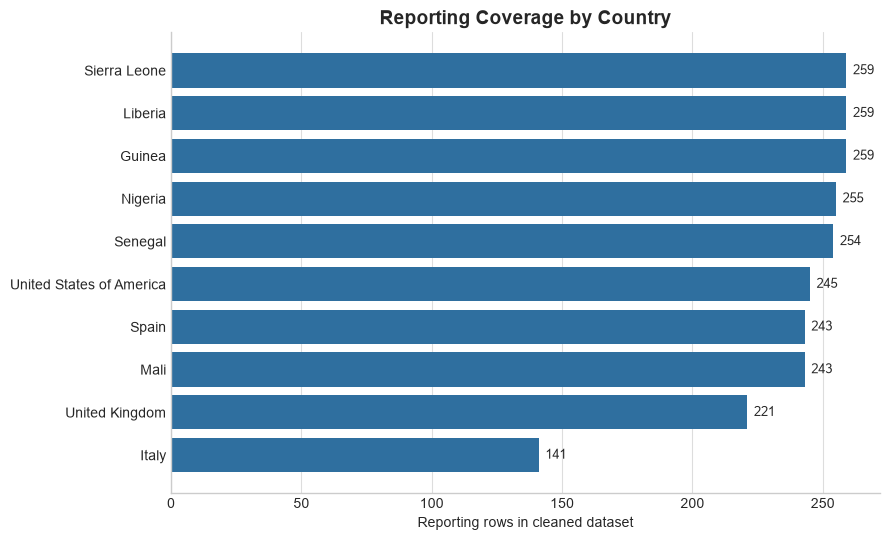

In [7]:
coverage_plot = reporting_coverage.sort_values("report_count", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(coverage_plot["country"], coverage_plot["report_count"], color=CHART_COLOR)
add_horizontal_bar_labels(ax, coverage_plot["report_count"].to_numpy())
style_axis(ax)
ax.set_title("Reporting Coverage by Country", fontsize=14, weight="bold")
ax.set_xlabel("Reporting rows in cleaned dataset")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(format_count))
plt.tight_layout()
plt.show()


### Chart Interpretation: Reporting Coverage

The chart indicates that reporting frequency varies across countries in the cleaned dataset. Sierra Leone, Liberia, and Guinea have the most complete reporting coverage, while countries with imported or limited outbreaks generally have fewer rows.

This should be interpreted as dataset coverage only. It does not mean that countries with more reporting rows had worse outbreaks.


In [8]:
display(
    reporting_coverage.assign(
        first_report=reporting_coverage["first_report"].dt.date,
        last_report=reporting_coverage["last_report"].dt.date,
    )
)


,country,first_report,last_report,report_count
0,Guinea,2014-08-29,2016-03-23,259
1,Liberia,2014-08-29,2016-03-23,259
2,Sierra Leone,2014-08-29,2016-03-23,259
3,Nigeria,2014-08-29,2016-03-23,255
4,Senegal,2014-09-05,2016-03-23,254
5,United States of America,2014-10-03,2016-03-23,245
6,Mali,2014-10-25,2016-03-23,243
7,Spain,2014-10-10,2016-03-23,243
8,United Kingdom,2015-01-02,2016-03-23,221
9,Italy,2015-05-14,2016-03-23,141


### Transition: From Coverage to Burden

With reporting coverage established, the notebook can move to burden comparisons. The next section uses country-level cumulative totals, while continuing to keep dataset scope and reporting caveats visible.


## 5. Outbreak Scale in Context

WHO describes the 2014-2016 West Africa Ebola outbreak as historically severe, with broader headline totals that may not match this project's filtered dataset exactly. The charts below therefore use cautious project-dataset wording: they compare cumulative confirmed/probable/suspected counts within the cleaned `main_countries` dataset.

The purpose of this section is to show scale and concentration, not to reconcile every public total.


In [9]:
burden_summary = make_burden_summary(main_countries)


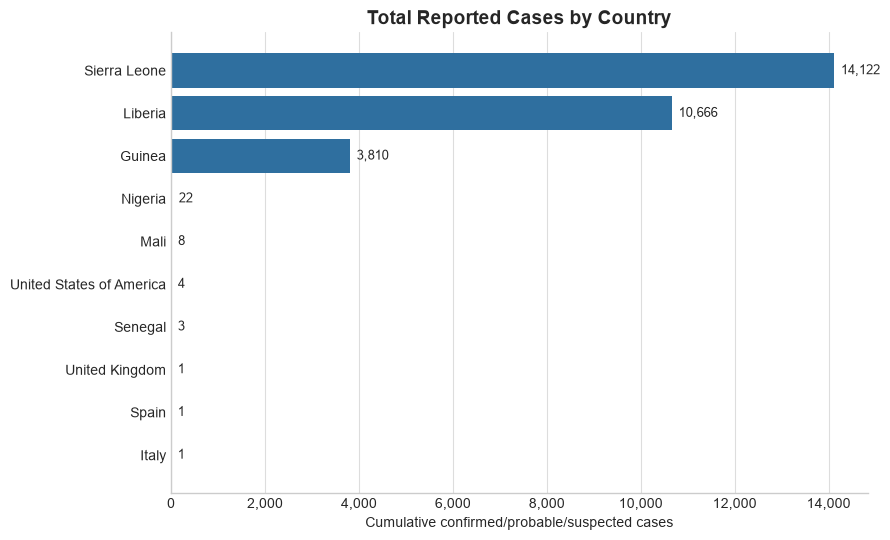

In [10]:
cases_plot = burden_summary.sort_values("total_cases", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(cases_plot["country"], cases_plot["total_cases"], color=CHART_COLOR)
add_horizontal_bar_labels(ax, cases_plot["total_cases"].to_numpy())
style_axis(ax)
ax.set_title("Total Reported Cases by Country", fontsize=14, weight="bold")
ax.set_xlabel("Cumulative confirmed/probable/suspected cases")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(format_count))
plt.tight_layout()
plt.show()


### Chart Interpretation: Total Reported Cases

Within the cleaned project dataset, cumulative reported cases are concentrated in Sierra Leone, Liberia, and Guinea. The imported or limited outbreaks in other countries appear much smaller on the same scale.

These values are project-dataset totals based on selected confirmed/probable/suspected indicators, not official WHO headline totals.


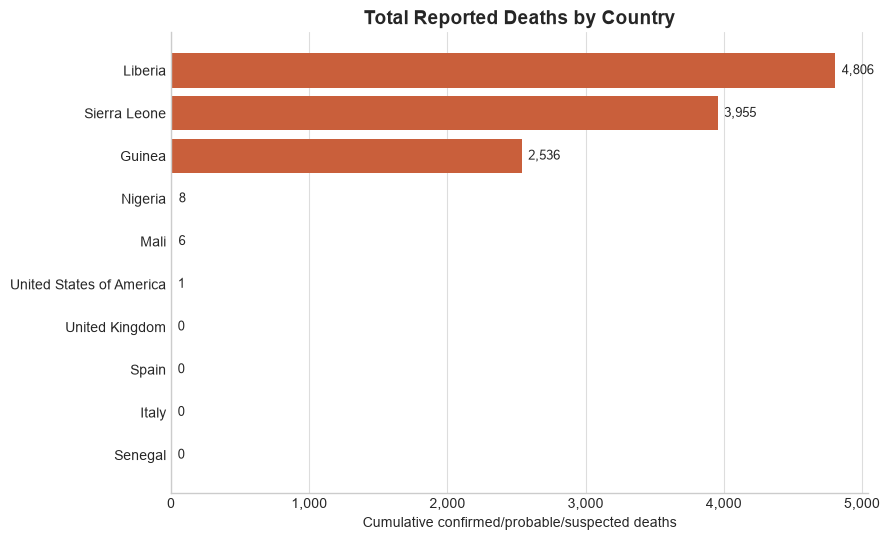

In [11]:
deaths_plot = burden_summary.sort_values("total_deaths", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(deaths_plot["country"], deaths_plot["total_deaths"], color=ACCENT_COLOR)
add_horizontal_bar_labels(ax, deaths_plot["total_deaths"].to_numpy())
style_axis(ax)
ax.set_title("Total Reported Deaths by Country", fontsize=14, weight="bold")
ax.set_xlabel("Cumulative confirmed/probable/suspected deaths")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(format_count))
plt.tight_layout()
plt.show()


### Chart Interpretation: Total Reported Deaths

The deaths chart shows a similar concentration of reported mortality burden in Liberia, Sierra Leone, and Guinea. The ordering differs from the cases chart, which is a reminder that case burden and death burden should not be collapsed into one interpretation.

Deaths are compared within the processed dataset only and should be read alongside case definitions, reporting coverage, and CFR denominator caveats.


,country,total_cases,total_deaths,share_of_total_cases,share_of_total_deaths
0,Sierra Leone,14122.0,3955.0,49.31,34.96
1,Liberia,10666.0,4806.0,37.24,42.49
2,Guinea,3810.0,2536.0,13.30,22.42


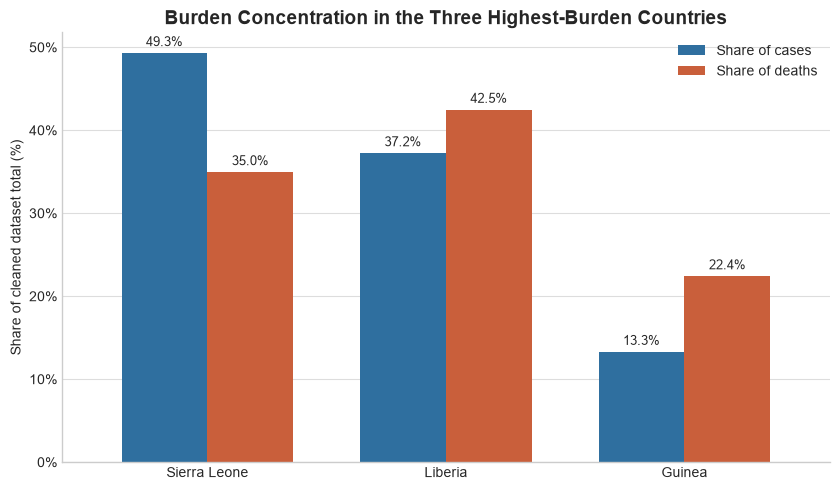

In [12]:
# This uses the cleaned main_countries dataset and should not be interpreted as WHO headline totals.
top_three_burden = burden_summary[burden_summary["country"].isin(TOP_THREE_COUNTRIES)].copy()
total_cases_all = burden_summary["total_cases"].sum()
total_deaths_all = burden_summary["total_deaths"].sum()

burden_concentration = top_three_burden.assign(
    share_of_total_cases=top_three_burden["total_cases"].div(total_cases_all).mul(100),
    share_of_total_deaths=top_three_burden["total_deaths"].div(total_deaths_all).mul(100),
).sort_values("total_cases", ascending=False)

burden_concentration_display = (
    burden_concentration[["country", "total_cases", "total_deaths", "share_of_total_cases", "share_of_total_deaths"]]
    .round({"share_of_total_cases": 2, "share_of_total_deaths": 2})
    .reset_index(drop=True)
)

display(burden_concentration_display)

concentration_plot = burden_concentration.set_index("country")[["share_of_total_cases", "share_of_total_deaths"]]
concentration_plot = concentration_plot.rename(
    columns={
        "share_of_total_cases": "Share of cases",
        "share_of_total_deaths": "Share of deaths",
    }
)

ax = concentration_plot.plot(
    kind="bar",
    figsize=(8.5, 5),
    color=[CHART_COLOR, ACCENT_COLOR],
    rot=0,
    width=0.72,
)
ax.set_title("Burden Concentration in the Three Highest-Burden Countries", fontsize=14, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Share of cleaned dataset total (%)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _position: f"{value:.0f}%"))
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8)
ax.grid(axis="x", visible=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)
plt.tight_layout()
plt.show()


### Chart Interpretation: Burden Concentration

The burden concentration chart makes the main country-burden pattern explicit: Sierra Leone, Liberia, and Guinea account for the overwhelming majority of reported cases and deaths in the cleaned project dataset.

The percentages are calculated from `main_countries`, not from WHO headline totals. The result supports a focused discussion of the three hardest-hit countries without implying that other countries were unimportant.


### Transition: From Burden to Mortality Patterns

The burden charts establish where reported cases and deaths were concentrated. The next step is to compare descriptive mortality ratios carefully, because CFR can look very different when a country has only a handful of reported cases.


## 6. Country Burden and Mortality Patterns

Country-level burden is summarized using maximum cumulative cases and deaths from the cleaned dataset. CFR is added as a descriptive death-to-case ratio, but it should be read with denominator context.

This section is especially careful with small outbreaks. A high percentage based on a very small denominator is not the same kind of evidence as a similar percentage in a high-burden country.


In [13]:
country_burden_table = calculate_cfr(burden_summary).sort_values(
    ["total_cases", "country"], ascending=[False, True]
)

country_summary = country_burden_table.merge(reporting_coverage, on="country", how="left")


In [14]:
display(
    country_summary.assign(
        first_report=country_summary["first_report"].dt.date,
        last_report=country_summary["last_report"].dt.date,
    )[["country", "total_cases", "total_deaths", "cfr_percent", "first_report", "last_report", "report_count"]]
    .round({"cfr_percent": 2})
    .reset_index(drop=True)
)


,country,total_cases,total_deaths,cfr_percent,first_report,last_report,report_count
0,Sierra Leone,14122.0,3955.0,28.01,2014-08-29,2016-03-23,259
1,Liberia,10666.0,4806.0,45.06,2014-08-29,2016-03-23,259
2,Guinea,3810.0,2536.0,66.56,2014-08-29,2016-03-23,259
3,Nigeria,22.0,8.0,36.36,2014-08-29,2016-03-23,255
4,Mali,8.0,6.0,75.00,2014-10-25,2016-03-23,243
5,United States of America,4.0,1.0,25.00,2014-10-03,2016-03-23,245
6,Senegal,3.0,0.0,0.00,2014-09-05,2016-03-23,254
7,Italy,1.0,0.0,0.00,2015-05-14,2016-03-23,141
8,Spain,1.0,0.0,0.00,2014-10-10,2016-03-23,243
9,United Kingdom,1.0,0.0,0.00,2015-01-02,2016-03-23,221


## 7. CFR Denominator-Banded Interpretation

CFR values are useful only when the denominator is visible. This section separates high-burden countries from low-burden countries so that small outbreaks do not dominate the interpretation.

The chart labels each country with total reported cases. The denominator bands are interpretive aids, not epidemiological categories.


In [15]:
def assign_denominator_band(total_cases):
    """Classify countries into broad denominator bands for CFR interpretation."""
    if total_cases >= 100:
        return "high burden (100+ cases)"
    return "low burden (<100 cases)"


cfr_denominator_bands = country_burden_table.assign(
    denominator_band=country_burden_table["total_cases"].apply(assign_denominator_band)
)[["country", "total_cases", "total_deaths", "cfr_percent", "denominator_band"]].sort_values(
    ["denominator_band", "total_cases"], ascending=[True, False]
)


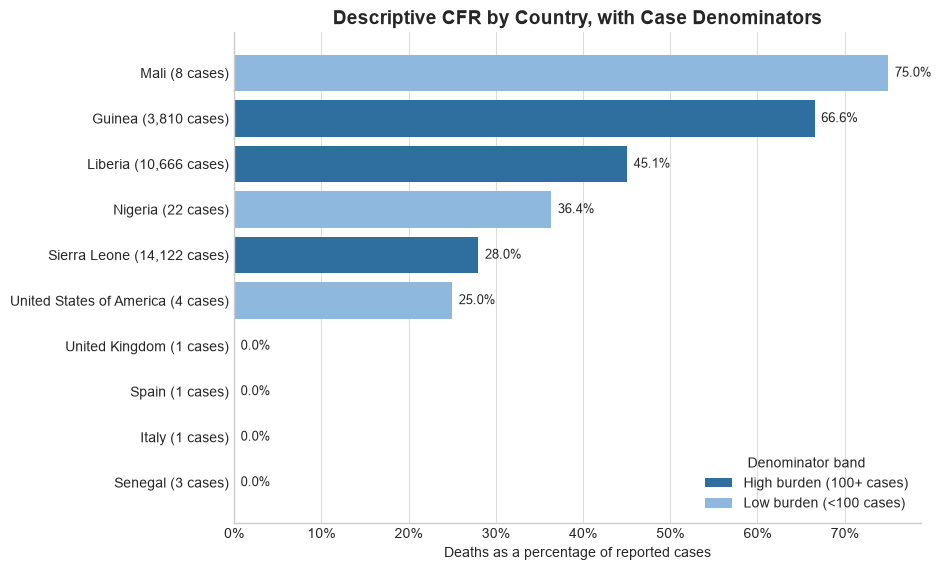

In [16]:
cfr_plot = cfr_denominator_bands.sort_values("cfr_percent", ascending=True).copy()
cfr_plot["country_label"] = cfr_plot.apply(
    lambda row: f"{row['country']} ({row['total_cases']:,.0f} cases)", axis=1
)
cfr_colors = cfr_plot["denominator_band"].map(
    {"high burden (100+ cases)": CHART_COLOR, "low burden (<100 cases)": SECONDARY_COLOR}
)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.barh(cfr_plot["country_label"], cfr_plot["cfr_percent"], color=cfr_colors)
add_horizontal_bar_labels(
    ax,
    cfr_plot["cfr_percent"].to_numpy(),
    formatter=lambda value, _position=None: f"{value:.1f}%",
)
style_axis(ax)
ax.set_title("Descriptive CFR by Country, with Case Denominators", fontsize=14, weight="bold")
ax.set_xlabel("Deaths as a percentage of reported cases")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _position: f"{value:.0f}%"))
denominator_legend = [
    Patch(facecolor=CHART_COLOR, label="High burden (100+ cases)"),
    Patch(facecolor=SECONDARY_COLOR, label="Low burden (<100 cases)"),
]
ax.legend(
    handles=denominator_legend,
    title="Denominator band",
    frameon=False,
    loc="lower right",
)
plt.tight_layout()
plt.show()


### Chart Interpretation: CFR Denominator-Aware Chart

The CFR chart suggests that descriptive death-to-case ratios vary substantially across countries, but the denominator labels change how the chart should be read. Although Mali records the highest descriptive CFR in the cleaned dataset, its outbreak involved only 8 reported cases. Larger outbreaks in Liberia, Sierra Leone, and Guinea account for the overwhelming majority of Ebola-related deaths in `main_countries`.

CFR values for very small case counts should be treated as descriptive ratios rather than stable country-level mortality estimates.


In [17]:
display(cfr_denominator_bands.round({"cfr_percent": 2}).reset_index(drop=True))


,country,total_cases,total_deaths,cfr_percent,denominator_band
0,Sierra Leone,14122.0,3955.0,28.01,high burden (100+ cases)
1,Liberia,10666.0,4806.0,45.06,high burden (100+ cases)
2,Guinea,3810.0,2536.0,66.56,high burden (100+ cases)
3,Nigeria,22.0,8.0,36.36,low burden (<100 cases)
4,Mali,8.0,6.0,75.00,low burden (<100 cases)
5,United States of America,4.0,1.0,25.00,low burden (<100 cases)
6,Senegal,3.0,0.0,0.00,low burden (<100 cases)
7,Italy,1.0,0.0,0.00,low burden (<100 cases)
8,Spain,1.0,0.0,0.00,low burden (<100 cases)
9,United Kingdom,1.0,0.0,0.00,low burden (<100 cases)


### Transition: From Ratios to Time-Series Shape

After country totals and CFR context, the analysis shifts from cross-country comparison to time evolution. The next section focuses on Sierra Leone, Liberia, and Guinea because they carry the overwhelming majority of reported burden in the cleaned dataset.


## 8. Time-Series Evolution

The time-series section describes how cumulative reported cases and deaths evolved in Sierra Leone, Liberia, and Guinea. These curves show reported cumulative totals, not incidence.

A derived `new_cases` series is included to make changes in cumulative totals easier to inspect, but it should be interpreted cautiously because it is calculated from cumulative data and may reflect reporting revisions or irregular reporting intervals.


In [18]:
top3 = (
    main_countries[main_countries["Country"].isin(TOP_THREE_COUNTRIES)]
    .copy()
    .sort_values(["Country", "Date"])
    .reset_index(drop=True)
)

missing_top3 = sorted(set(TOP_THREE_COUNTRIES) - set(top3["Country"].unique()))
if missing_top3:
    raise ValueError(f"Missing expected top-three countries: {missing_top3}")

top3_coverage = (
    top3.groupby("Country", as_index=False)
    .agg(
        first_report=("Date", "min"),
        last_report=("Date", "max"),
        report_count=("Date", "size"),
    )
    .rename(columns={"Country": "country"})
    .sort_values("country")
)

display(
    top3_coverage.assign(
        first_report=top3_coverage["first_report"].dt.date,
        last_report=top3_coverage["last_report"].dt.date,
    ).reset_index(drop=True)
)


,country,first_report,last_report,report_count
0,Guinea,2014-08-29,2016-03-23,259
1,Liberia,2014-08-29,2016-03-23,259
2,Sierra Leone,2014-08-29,2016-03-23,259


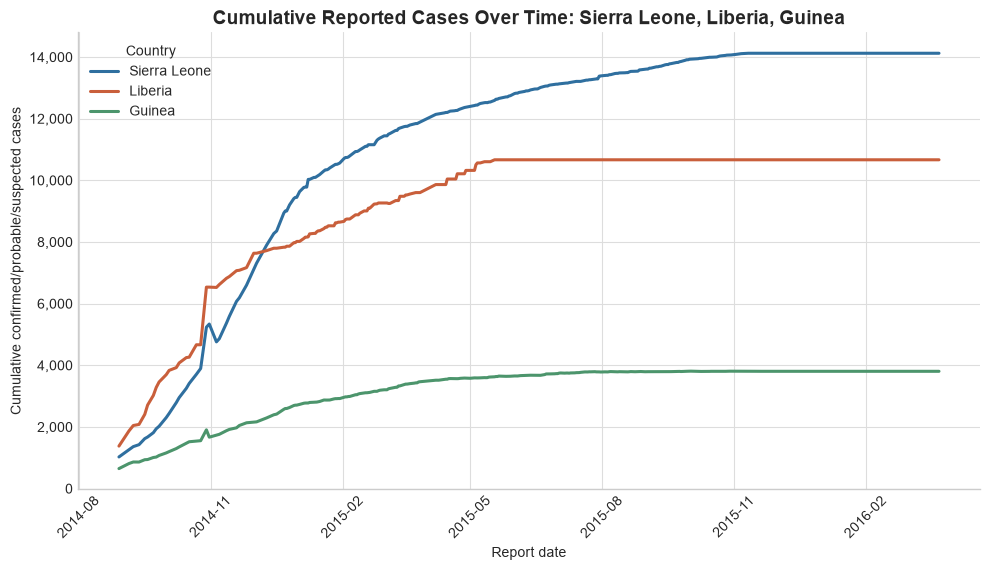

In [19]:
fig, ax = plt.subplots(figsize=(10, 5.8))

for country in TOP_THREE_COUNTRIES:
    country_data = top3[top3["Country"] == country]
    ax.plot(
        country_data["Date"],
        country_data["cases"],
        label=country,
        linewidth=2.2,
        color=LINE_COLORS[country],
    )

style_time_axis(ax)
ax.set_title("Cumulative Reported Cases Over Time: Sierra Leone, Liberia, Guinea", fontsize=14, weight="bold")
ax.set_xlabel("Report date")
ax.set_ylabel("Cumulative confirmed/probable/suspected cases")
ax.yaxis.set_major_formatter(FuncFormatter(format_count))
ax.legend(title="Country", frameon=False)
plt.tight_layout()
plt.show()


### Chart Interpretation: Cumulative Cases Over Time

The cumulative cases chart shows different growth patterns across the three hardest-hit countries. Sierra Leone eventually reaches the highest cumulative reported case total in the cleaned dataset, while Liberia rises sharply and then plateaus earlier.

The chart describes reported cumulative totals only. It should not be read as evidence that a specific intervention explains a change in trajectory.


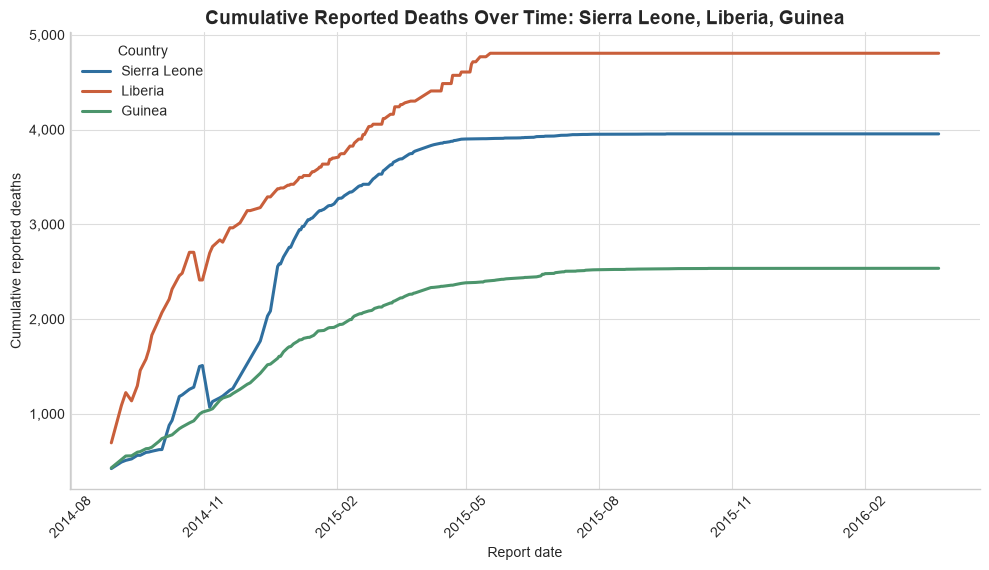

In [20]:
fig, ax = plt.subplots(figsize=(10, 5.8))

for country in TOP_THREE_COUNTRIES:
    country_data = top3[top3["Country"] == country]
    ax.plot(
        country_data["Date"],
        country_data["deaths"],
        label=country,
        linewidth=2.2,
        color=LINE_COLORS[country],
    )

style_time_axis(ax)
ax.set_title("Cumulative Reported Deaths Over Time: Sierra Leone, Liberia, Guinea", fontsize=14, weight="bold")
ax.set_xlabel("Report date")
ax.set_ylabel("Cumulative reported deaths")
ax.yaxis.set_major_formatter(FuncFormatter(format_count))
ax.legend(title="Country", frameon=False)
plt.tight_layout()
plt.show()


### Chart Interpretation: Cumulative Deaths Over Time

The cumulative deaths chart shows that Liberia has the highest reported death total in the cleaned dataset, even though Sierra Leone has the highest reported case total. Guinea's cumulative deaths rise more gradually and remain lower than Liberia and Sierra Leone.

These are descriptive trends. Reporting intervals, retrospective updates, and case definitions may affect the shape of the curves.


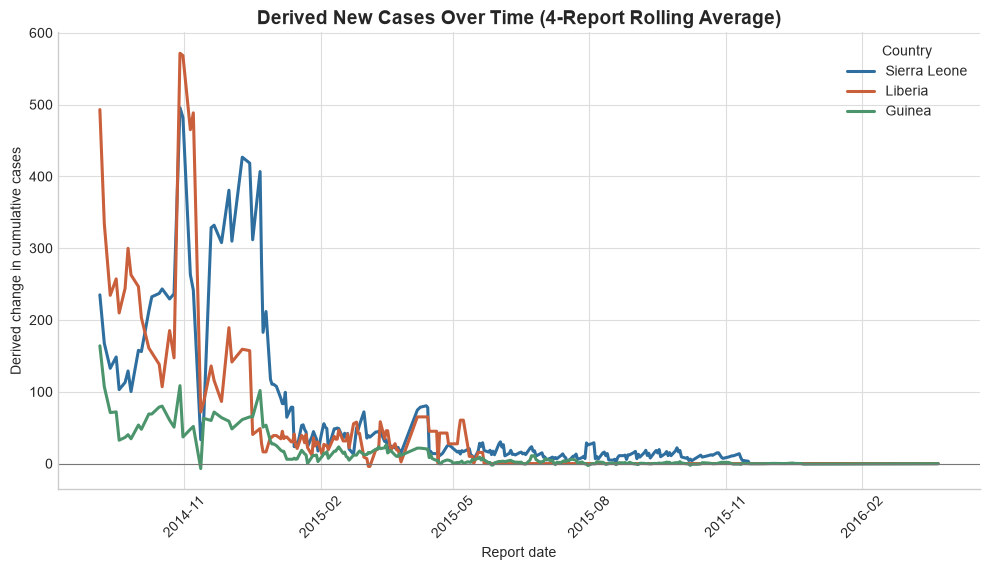

In [21]:
top3 = top3.sort_values(["Country", "Date"]).copy()
top3["new_cases"] = top3.groupby("Country")["cases"].diff()
top3["new_cases_smoothed"] = top3.groupby("Country")["new_cases"].transform(
    lambda values: values.rolling(window=4, min_periods=1).mean()
)

fig, ax = plt.subplots(figsize=(10, 5.8))

for country in TOP_THREE_COUNTRIES:
    country_data = top3[top3["Country"] == country]
    ax.plot(
        country_data["Date"],
        country_data["new_cases_smoothed"],
        label=country,
        linewidth=2.2,
        color=LINE_COLORS[country],
    )

style_time_axis(ax)
ax.axhline(0, color="#777777", linewidth=0.8)
ax.set_title("Derived New Cases Over Time (4-Report Rolling Average)", fontsize=14, weight="bold")
ax.set_xlabel("Report date")
ax.set_ylabel("Derived change in cumulative cases")
ax.yaxis.set_major_formatter(FuncFormatter(format_count))
ax.legend(title="Country", frameon=False)
plt.tight_layout()
plt.show()


### Chart Interpretation: Derived New Cases Over Time

The smoothed derived `new_cases` chart suggests periods of faster and slower growth in reported cumulative cases. It is useful for seeing broad timing patterns that are harder to read from cumulative curves alone.

This is not true daily incidence. `new_cases` is calculated from period-to-period differences in cumulative totals, and the 4-report rolling average is a visual smoothing aid rather than a directly reported epidemiological measure.


### Transition: From Time-Series Description to Response Context

The time-series patterns raise natural questions about response timing, but the dataset alone cannot answer them. The next section adds source-backed milestones as context while keeping intervention interpretation separate from causal attribution.


## 9. Intervention Timeline Context

This section adds a small number of source-backed public health milestones to the regional time-series view. The included markers are limited to events documented in the intervention timeline: the 2014-08-08 PHEIC declaration and the 2016-01-14 WHO end-phase statement that known transmission chains had stopped while flare-up risk remained.

These milestones orient the reader. They do not estimate when interventions were implemented in each country, and they should not be interpreted as evidence that interventions explain observed changes in the curves.


In [22]:
intervention_milestones = pd.DataFrame(
    [
        {
            "date_or_period": "2014-08-08",
            "location": "West Africa / international",
            "milestone": "WHO declared a Public Health Emergency of International Concern (PHEIC).",
            "evidence_ids": "W3, CL3",
            "source": "WHO IHR Emergency Committee statement",
            "caveat": "Valid timeline marker, not evidence of immediate implementation or effect.",
        },
        {
            "date_or_period": "2016-01-14",
            "location": "West Africa",
            "milestone": "WHO stated all known transmission chains had stopped, while flare-up risk remained.",
            "evidence_ids": "W6",
            "source": "WHO end-phase release",
            "caveat": "End-phase context; does not identify when case trends first changed.",
        },
        {
            "date_or_period": "2016-06",
            "location": "West Africa",
            "milestone": "WHO overview states the outbreak was declared over in June 2016.",
            "evidence_ids": "W1, W2",
            "source": "WHO outbreak overview",
            "caveat": "Month-level endpoint; not used as an exact chart annotation in the processed dataset window.",
        },
    ]
)

display(intervention_milestones)


,date_or_period,location,milestone,evidence_ids,source,caveat
0,2014-08-08,West Africa / international,WHO declared a Public Health Emergency of Inte...,"W3, CL3",WHO IHR Emergency Committee statement,"Valid timeline marker, not evidence of immedia..."
1,2016-01-14,West Africa,WHO stated all known transmission chains had s...,W6,WHO end-phase release,End-phase context; does not identify when case...
2,2016-06,West Africa,WHO overview states the outbreak was declared ...,"W1, W2",WHO outbreak overview,Month-level endpoint; not used as an exact cha...


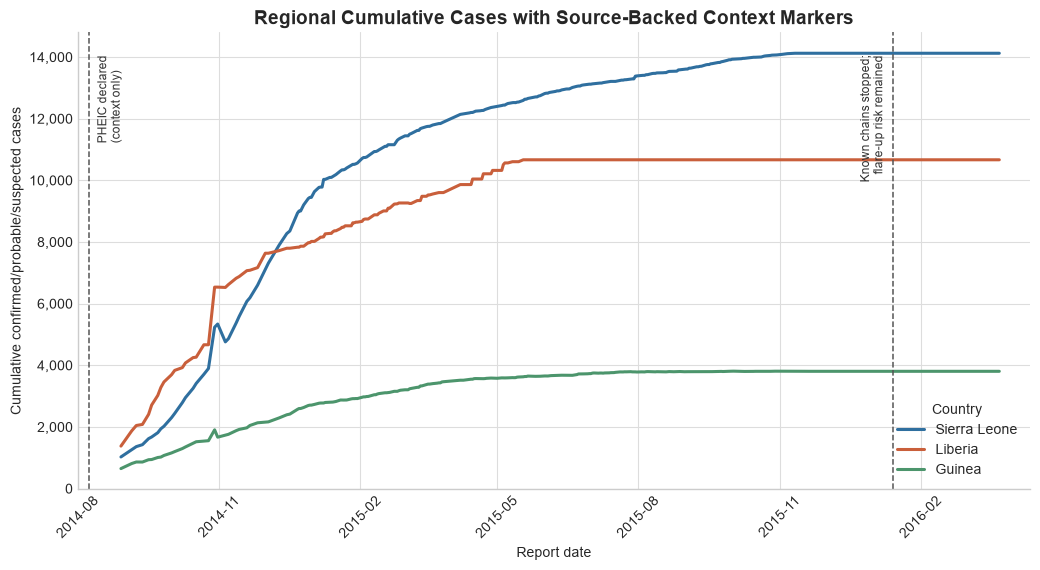

In [23]:
regional_context_markers = [
    {
        "date": pd.Timestamp("2014-08-08"),
        "label": "PHEIC declared\n(context only)",
        "evidence_ids": "W3, CL3",
        "label_offset_days": 5,
        "ha": "left",
    },
    {
        "date": pd.Timestamp("2016-01-14"),
        "label": "Known chains stopped;\nflare-up risk remained",
        "evidence_ids": "W6",
        "label_offset_days": -5,
        "ha": "right",
    },
]

fig, ax = plt.subplots(figsize=(10.5, 5.8))

for country in TOP_THREE_COUNTRIES:
    country_data = top3[top3["Country"] == country]
    ax.plot(
        country_data["Date"],
        country_data["cases"],
        label=country,
        linewidth=2.2,
        color=LINE_COLORS[country],
    )

style_time_axis(ax)
ax.set_title(
    "Regional Cumulative Cases with Source-Backed Context Markers",
    fontsize=14,
    weight="bold",
)
ax.set_xlabel("Report date")
ax.set_ylabel("Cumulative confirmed/probable/suspected cases")
ax.yaxis.set_major_formatter(FuncFormatter(format_count))
ax.set_xlim(pd.Timestamp("2014-08-01"), top3["Date"].max() + pd.Timedelta(days=20))

for marker in regional_context_markers:
    ax.axvline(marker["date"], color="#555555", linestyle="--", linewidth=1.1)
    ax.text(
        marker["date"] + pd.Timedelta(days=marker["label_offset_days"]),
        ax.get_ylim()[1] * 0.95,
        marker["label"],
        rotation=90,
        va="top",
        ha=marker["ha"],
        fontsize=8.5,
        color="#333333",
        clip_on=False,
    )

ax.legend(title="Country", frameon=False, loc="lower right")
plt.tight_layout()
plt.show()


### Interpretation: Intervention Timeline Context

The regional context chart places documented WHO milestones alongside cumulative reported cases for Sierra Leone, Liberia, and Guinea. The markers are useful reference points for the story, especially because they separate the emergency declaration period from the later end-phase period.

The chart should be interpreted cautiously. It does not include treatment-center or safe-burial markers because exact country-specific dates remain under-sourced in the current evidence base, and it does not support causal claims from timing alone.


## 10. Nigeria Contrast Case

Nigeria is included as a documented contrast case because CDC and academic sources provide unusually specific evidence about its imported index case, emergency coordination, contact tracing, isolation/case management, and communication activities.

The comparison is intentionally limited. Nigeria's outbreak was imported and much smaller than the widespread transmission in Sierra Leone, Liberia, and Guinea. It helps illustrate a documented response package, but it is not a direct counterfactual for what would have happened elsewhere.


In [24]:
nigeria = main_countries[main_countries["Country"] == "Nigeria"].copy().sort_values("Date")

if nigeria.empty:
    raise ValueError("Nigeria rows were not found in the processed dataset.")

nigeria_total_cases = nigeria["cases"].max()
nigeria_total_deaths = nigeria["deaths"].max()
nigeria_summary_table = pd.DataFrame(
    [
        {
            "country": "Nigeria",
            "total_cases": nigeria_total_cases,
            "total_deaths": nigeria_total_deaths,
            "first_report": nigeria["Date"].min().date(),
            "last_report": nigeria["Date"].max().date(),
            "cfr_percent": (nigeria_total_deaths / nigeria_total_cases) * 100,
        }
    ]
)

display(nigeria_summary_table.round({"cfr_percent": 2}))


,country,total_cases,total_deaths,first_report,last_report,cfr_percent
0,Nigeria,22.0,8.0,2014-08-29,2016-03-23,36.36


In [25]:
nigeria_milestones = pd.DataFrame(
    [
        {
            "date": "2014-07-20",
            "milestone": "Imported index case arrived from Liberia.",
            "evidence_ids": "C1",
            "source": "CDC MMWR Nigeria report; Otu et al.",
            "caveat": "Nigeria-specific imported outbreak context.",
        },
        {
            "date": "2014-07-23",
            "milestone": "Incident coordination / Ebola emergency response began.",
            "evidence_ids": "C2, A2",
            "source": "CDC MMWR Nigeria report; Otu et al.",
            "caveat": "Exact naming differs by source; use as documented coordination milestone.",
        },
        {
            "date": "2014-09-24",
            "milestone": "Contact tracing scale documented: 894 contacts and about 18,500 face-to-face visits.",
            "evidence_ids": "C3, CL6",
            "source": "CDC MMWR Nigeria report",
            "caveat": "Activity metric, not a causal estimate.",
        },
        {
            "date": "2014-09-24",
            "milestone": "Isolation/case management status documented; suspected and confirmed wards were empty.",
            "evidence_ids": "C4, C5",
            "source": "CDC MMWR Nigeria report",
            "caveat": "Report date, not the formal WHO Ebola-free endpoint.",
        },
        {
            "date": "2014-09-24",
            "milestone": "Public communication / social mobilization documented around contacts.",
            "evidence_ids": "C6, A3, CL7",
            "source": "CDC MMWR Nigeria report; Otu et al.",
            "caveat": "Reach does not quantify trust, comprehension, or behavior change.",
        },
        {
            "date": "2014-10-20",
            "milestone": "WHO declared Nigeria free of EVD, as reported by Otu et al.",
            "evidence_ids": "A1, A2",
            "source": "Otu et al. citing WHO",
            "caveat": "Prefer a direct WHO statement if retrieved before final publication.",
        },
    ]
)

display(nigeria_milestones)


,date,milestone,evidence_ids,source,caveat
0,2014-07-20,Imported index case arrived from Liberia.,C1,CDC MMWR Nigeria report; Otu et al.,Nigeria-specific imported outbreak context.
1,2014-07-23,Incident coordination / Ebola emergency respon...,"C2, A2",CDC MMWR Nigeria report; Otu et al.,Exact naming differs by source; use as documen...
2,2014-09-24,Contact tracing scale documented: 894 contacts...,"C3, CL6",CDC MMWR Nigeria report,"Activity metric, not a causal estimate."
3,2014-09-24,Isolation/case management status documented; s...,"C4, C5",CDC MMWR Nigeria report,"Report date, not the formal WHO Ebola-free end..."
4,2014-09-24,Public communication / social mobilization doc...,"C6, A3, CL7",CDC MMWR Nigeria report; Otu et al.,"Reach does not quantify trust, comprehension, ..."
5,2014-10-20,"WHO declared Nigeria free of EVD, as reported ...","A1, A2",Otu et al. citing WHO,Prefer a direct WHO statement if retrieved bef...


In [26]:
nigeria_evidence_table = pd.DataFrame(
    [
        {
            "response_action": "Rapid coordination",
            "evidence": "Incident Management Center / EOC / IMS structure documented.",
            "source": "CDC MMWR; Otu et al.",
            "evidence_ids": "C2, A1, A2, CL5",
            "limitation": "Supports response description, not causal evidence by itself.",
        },
        {
            "response_action": "Contact tracing",
            "evidence": "894 contacts and approximately 18,500 face-to-face visits documented.",
            "source": "CDC MMWR",
            "evidence_ids": "C3, CL6",
            "limitation": "Applies to Nigeria; not a measured comparison against the hardest-hit countries.",
        },
        {
            "response_action": "Isolation / case management",
            "evidence": "Suspected and confirmed case wards, case management, and laboratory confirmation documented.",
            "source": "CDC MMWR; Otu et al.",
            "evidence_ids": "C4, A4, CL5",
            "limitation": "Does not establish identical availability or effect across locations.",
        },
        {
            "response_action": "Communication / social mobilization",
            "evidence": "House-to-house mobilization reached about 26,000 households; communication channels and rumors documented.",
            "source": "CDC MMWR; Otu et al.",
            "evidence_ids": "C6, A3, CL7",
            "limitation": "Activity evidence does not quantify trust or behavior change.",
        },
        {
            "response_action": "Multi-component response",
            "evidence": "CDC and academic sources describe coordinated teams spanning surveillance, case management, laboratory services, entry points, communication, and management.",
            "source": "CDC MMWR; Otu et al.; Fasina et al. abstract",
            "evidence_ids": "C2-C7, A1-A5, CL5",
            "limitation": "Do not claim one intervention alone explains containment.",
        },
    ]
)

display(nigeria_evidence_table)


,response_action,evidence,source,evidence_ids,limitation
0,Rapid coordination,Incident Management Center / EOC / IMS structu...,CDC MMWR; Otu et al.,"C2, A1, A2, CL5","Supports response description, not causal evid..."
1,Contact tracing,"894 contacts and approximately 18,500 face-to-...",CDC MMWR,"C3, CL6",Applies to Nigeria; not a measured comparison ...
2,Isolation / case management,"Suspected and confirmed case wards, case manag...",CDC MMWR; Otu et al.,"C4, A4, CL5",Does not establish identical availability or e...
3,Communication / social mobilization,"House-to-house mobilization reached about 26,0...",CDC MMWR; Otu et al.,"C6, A3, CL7",Activity evidence does not quantify trust or b...
4,Multi-component response,CDC and academic sources describe coordinated ...,CDC MMWR; Otu et al.; Fasina et al. abstract,"C2-C7, A1-A5, CL5",Do not claim one intervention alone explains c...


### Interpretation: Nigeria Contrast Case

Nigeria's evidence table supports a cautious response narrative: CDC and academic sources describe rapid coordination, intensive contact tracing, isolation/case management, laboratory confirmation, and communication activities.

The safest interpretation is that Nigeria provides a well-documented contrast case. The evidence does not isolate one intervention as the sole explanation for containment, and it does not imply that the same approach would have produced identical results in the three hardest-hit countries.


## 11. What the Evidence Can and Cannot Say

This section separates claim-ready statements from interpretations that remain under-supported. The goal is to make the notebook's evidence boundaries visible before drawing lessons.

Dataset evidence can support descriptive findings about reporting coverage, burden, CFR, and time-series shape. WHO, CDC, and academic sources can support official milestones and Nigeria response descriptions. They do not currently support detailed causal claims about specific regional interventions driving observed trend changes.


In [27]:
claim_readiness_table = pd.DataFrame(
    [
        {
            "claim": "The 2014-2016 West Africa outbreak was historically severe.",
            "evidence_ids": "W1, CL1",
            "evidence_strength": "High",
            "notebook_use": "Ready as opening context.",
            "caveat": "WHO headline totals may not match cleaned project dataset totals exactly.",
        },
        {
            "claim": "Burden was concentrated in Sierra Leone, Liberia, and Guinea in the cleaned project dataset.",
            "evidence_ids": "D3, CL2",
            "evidence_strength": "Medium-High",
            "notebook_use": "Ready for descriptive burden interpretation.",
            "caveat": "Use project-dataset wording, not WHO headline-total wording.",
        },
        {
            "claim": "The PHEIC declaration is a valid timeline marker.",
            "evidence_ids": "W3, CL3",
            "evidence_strength": "High",
            "notebook_use": "Ready as contextual marker.",
            "caveat": "Should not be interpreted as causal evidence of trend change.",
        },
        {
            "claim": "Nigeria used rapid coordination and intensive contact tracing.",
            "evidence_ids": "C2, C3, A1, A2, CL5, CL6",
            "evidence_strength": "High for description",
            "notebook_use": "Ready for Nigeria contrast section.",
            "caveat": "Nigeria is a documented contrast case, not a direct counterfactual.",
        },
        {
            "claim": "Response was multi-component rather than a single-intervention story.",
            "evidence_ids": "W5, C2-C7, A1-A5, CL5",
            "evidence_strength": "High for framework; Medium for causal interpretation",
            "notebook_use": "Ready as response-context framing.",
            "caveat": "Do not isolate one component as the sole cause of containment.",
        },
        {
            "claim": "Specific interventions explain regional declines in the three hardest-hit countries.",
            "evidence_ids": "CL3, CL8, CL9",
            "evidence_strength": "Low",
            "notebook_use": "Not ready; limitation only.",
            "caveat": "Time-series charts and markers are contextual, not causal evidence.",
        },
        {
            "claim": "Safe burials explain observed trend changes.",
            "evidence_ids": "W7, CL9",
            "evidence_strength": "Low for dated regional trend explanation",
            "notebook_use": "Cautious context or evidence gap only.",
            "caveat": "No country-specific safe-burial implementation date series is currently extracted.",
        },
        {
            "claim": "Treatment centers explain observed trend changes.",
            "evidence_ids": "W5, CL8",
            "evidence_strength": "Low for dated regional trend explanation",
            "notebook_use": "Cautious context or evidence gap only.",
            "caveat": "Treatment-center timing remains under-sourced for Guinea, Liberia, and Sierra Leone.",
        },
        {
            "claim": "Misinformation drove regional trends.",
            "evidence_ids": "W4, C7, A3, CL7",
            "evidence_strength": "Low-Medium for relevance; Low for regional trend explanation",
            "notebook_use": "Evidence gap or cautious context only.",
            "caveat": "Nigeria and WHO-level evidence do not establish regional trend causation.",
        },
    ]
)

display(claim_readiness_table[["claim", "evidence_strength", "notebook_use", "caveat", "evidence_ids"]])


,claim,evidence_strength,notebook_use,caveat,evidence_ids
0,The 2014-2016 West Africa outbreak was histori...,High,Ready as opening context.,WHO headline totals may not match cleaned proj...,"W1, CL1"
1,"Burden was concentrated in Sierra Leone, Liber...",Medium-High,Ready for descriptive burden interpretation.,"Use project-dataset wording, not WHO headline-...","D3, CL2"
2,The PHEIC declaration is a valid timeline marker.,High,Ready as contextual marker.,Should not be interpreted as causal evidence o...,"W3, CL3"
3,Nigeria used rapid coordination and intensive ...,High for description,Ready for Nigeria contrast section.,"Nigeria is a documented contrast case, not a d...","C2, C3, A1, A2, CL5, CL6"
4,Response was multi-component rather than a sin...,High for framework; Medium for causal interpre...,Ready as response-context framing.,Do not isolate one component as the sole cause...,"W5, C2-C7, A1-A5, CL5"
5,Specific interventions explain regional declin...,Low,Not ready; limitation only.,"Time-series charts and markers are contextual,...","CL3, CL8, CL9"
6,Safe burials explain observed trend changes.,Low for dated regional trend explanation,Cautious context or evidence gap only.,No country-specific safe-burial implementation...,"W7, CL9"
7,Treatment centers explain observed trend changes.,Low for dated regional trend explanation,Cautious context or evidence gap only.,Treatment-center timing remains under-sourced ...,"W5, CL8"
8,Misinformation drove regional trends.,Low-Medium for relevance; Low for regional tre...,Evidence gap or cautious context only.,Nigeria and WHO-level evidence do not establis...,"W4, C7, A3, CL7"


### Interpretation: Evidence Boundaries

The claim-readiness table is the guardrail for the final narrative. It identifies which statements are ready for notebook use and which should remain as limitations or open questions.

The evidence is consistent with a multi-component response context, especially in the Nigeria case. It is not strong enough to attribute regional trend changes to specific interventions such as treatment centers, safe burials, or public trust dynamics without additional source-backed timing and causal evidence.


## 12. Lessons for Future Outbreaks

The evidence supports cautious lessons around coordinated outbreak response. WHO sources frame Ebola control as a package that includes emergency coordination, surveillance, contact tracing, case management, laboratory support, safe burial practices, and community engagement. CDC and academic sources describe Nigeria's response as similarly multi-component, combining coordination, contact tracing, isolation/case management, laboratory confirmation, and communication activities.

The most defensible lesson is about response capacity rather than single-cause explanation. Outbreak response appears strongest when systems can coordinate quickly, trace and monitor contacts, isolate and manage suspected or confirmed cases, communicate clearly, and maintain surveillance after apparent interruption.

Nigeria makes that lesson concrete, but only within limits. It is a documented contrast case, not a direct counterfactual for Guinea, Liberia, or Sierra Leone. Differences in transmission scale, health-system capacity, timing, surveillance, geography, and social context mean the Nigeria evidence should inform questions and preparedness priorities, not universal formulas.


### Lessons Synthesis

For a portfolio reader, the lesson is as much methodological as public health oriented: a responsible analysis should separate descriptive patterns from causal interpretation. This notebook uses the data to show burden and trajectory, then uses sources to bound what can be said about response context.

The strongest closing message is that transparent data limitations and clear evidence boundaries are part of outbreak analysis, not an afterthought.


## 13. Limitations

This notebook uses a cleaned project dataset built from selected cumulative confirmed/probable/suspected case and death indicators. The totals are suitable for descriptive analysis within the project dataset, but they should not be treated as confirmed-only counts or exact WHO headline totals.

Reporting coverage varies by country, so time-series comparisons should be interpreted with care. The derived `new_cases` field is calculated from period-to-period changes in cumulative totals; it is not true daily incidence and may reflect reporting intervals, revisions, or corrections.

CFR values are descriptive ratios based on reported deaths divided by reported cases. They are especially unstable for countries with very small case counts, so low-denominator countries should not be ranked as if their CFR values were stable mortality estimates.

`Liberia 2` and `Guinea 2` remain excluded from the primary `main_countries` dataset to preserve one row per country-date. The reviewed documentation does not yet explain the literal meaning of those continuation labels, and merging them directly would create duplicate country-date rows.

The intervention evidence is also uneven. PHEIC and end-phase markers are valid context, but they do not establish intervention effects. Treatment-center and safe-burial dates remain under-sourced for a dated regional chart. Public trust and misinformation evidence is strongest for Nigeria and broader WHO context, but remains limited for explaining trends in the three hardest-hit countries. Detailed NEJM claims remain pending full-text extraction.


### Limitations Summary

| Limitation | Affected Interpretation | Mitigation in Notebook |
| --- | --- | --- |
| Combined confirmed/probable/suspected counts | Dataset totals are descriptive project totals, not confirmed-only counts. | State indicator scope in methods, tables, and chart caveats. |
| Variable reporting coverage | Time-series density does not equal outbreak severity. | Include reporting coverage before burden analysis. |
| Derived `new_cases` from cumulative totals | Derived changes are not true daily incidence. | Use cautious language and smoothing caveat. |
| Small CFR denominators | Low-count countries can produce unstable percentages. | Use denominator bands and avoid ranking small outbreaks as stable mortality estimates. |
| `Liberia 2` / `Guinea 2` unresolved | Continuation-label meaning remains unknown. | Exclude from `main_countries` to preserve country-date grain. |
| Intervention timing evidence gaps | Regional markers cannot establish causality. | Use PHEIC/end-phase markers as context only. |
| Treatment-center, safe-burial, trust, and misinformation gaps | Mechanism claims remain under-supported. | Keep these as limitations or cautious context until stronger sources are added. |


## 14. Conclusion

This notebook presents a cautious, evidence-backed analysis of the 2014-2016 Ebola outbreak. In the cleaned project dataset, reported cases and deaths are highly concentrated in Sierra Leone, Liberia, and Guinea. The descriptive results also show why interpretation requires context: reporting coverage varies, cumulative data do not directly measure incidence, and CFR values can be unstable when denominators are small.

The public health evidence adds context without turning the notebook into a causal model. WHO sources support the historical scale of the outbreak, the PHEIC declaration as a timeline marker, the multi-component nature of Ebola control, and the importance of continued surveillance after known transmission chains stopped. CDC and academic sources make Nigeria a documented contrast case, but not a direct counterfactual for the three hardest-hit countries.

The final story is therefore bounded but useful: the outbreak was historically severe, the cleaned dataset shows a concentrated burden, and source-backed response evidence points toward the importance of coordinated, multi-component preparedness. The notebook avoids claiming that specific interventions explain regional declines because the current evidence base does not support that level of causal interpretation.


## Reproducibility and Publication Notes

This notebook is designed to be rerun from a clean kernel. It recalculates summary tables and charts from `datasets/processed/master_cases_deaths.csv` and keeps outputs cleared in source control until rendered outputs are intentionally kept for publication.

Before public release, the remaining publication step is a final rendered-output review in Jupyter or GitHub preview to check that all tables and charts display as intended in the target viewing environment.
